# Computing temporal autocorrelation on detrended height, area, volume, mass

In [1]:
import sys
import json
import scipy as sc
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

from cmcrameri import cm
from matplotlib.ticker import MultipleLocator

sys.path.append("scripts/utils/")
from signal_filtering  import apply_lowpass
from matrix_operations import detrend_entire_matrix
from SegmentedCells    import SegmentedCells
from Correlations      import Autocorrelations
from Microscopes       import Tomocube, Holomonitor

data_path = '../../../../hdd_data/silja/Monolayers/'

In [2]:
# Set experimental parameters
min_hours = 4
n_0    = Tomocube().n0
alpha  = 0.19

In [3]:
# Plot settings
lw = 8

h_color = "b"
A_color = "orange"
V_color = "tab:green"
M_color = 'k'

In [4]:
# import dataset
datasets = [
            "MDCK_20250210_A2-1", 
            "MDCK_20250904_B1-1"
            ]


In [5]:
volume_list = []
area_list   = []
height_list = []
hours_list  = []
concentration_list = []
density_list   = []
duration_list  = []
min_track_list = []

for dataset in datasets:


    # Load segmented cells
    config = json.load(open(f"configs/{dataset}.json"))

    ### SET MICROSCOPE ###
    if config['microscope'] == "holomonitor": microscope = Holomonitor()
    elif config['microscope'] == "tomocube":  microscope = Tomocube()

    cells = SegmentedCells(f"{data_path}/cell_features/calibrated/{dataset}_cells.p")
    #density_mask = (cells.density > 1400) * (cells.density < 1600)
    density_list.append(cells.density)

    # apply lowpass filter to data. area is the only parameter directly related to segmentation, but since also 
    # the average height and average refractive index depends on the area, we also fi, mask=cells.A.mask)lter these
    area_lowpass   = np.ma.array(apply_lowpass(cells.A, cells.A.mask, cutoff=0.8, fs=1/microscope.frame_to_h, order=6), mask=cells.A.mask)
    height_lowpass = np.ma.array(apply_lowpass(cells.h, cells.h.mask, cutoff=0.8, fs=1/microscope.frame_to_h, order=6), mask=cells.h.mask)


    # remove short tracks and last data points
    volume_list.append((height_lowpass * area_lowpass))
    height_list.append(height_lowpass)
    area_list.append(area_lowpass)
    hours_list.append(np.arange(len(cells.x[:,0])) * microscope.frame_to_h)

    # save mass if tomocube
    if microscope.name == "tomocube":
        n_lowpass = np.ma.array(apply_lowpass(cells.n, cells.n.mask, cutoff=0.8, fs=1/microscope.frame_to_h, order=6), mask=cells.n.mask)
        concentration_list.append((n_lowpass - n_0) / alpha )


    # Save duration and track lengths
    duration_list.append(np.sum(~cells.A.mask, axis=0))
    min_track_list.append(min_hours / microscope.frame_to_h)



# Remove last indices in case of division
for height, area, volume, mass in zip(height_list, area_list, volume_list, concentration_list):
    n, m = area.shape

    for j in range(m):
        # indices of currently unmasked entries in column j
        unmasked_idx = np.where(~area.mask[:, j])[0]
        # take last up to 5 of them
        to_mask = unmasked_idx[-4:]
        # set those mask positions to True
        area.mask[to_mask, j]   = True
        height.mask[to_mask, j] = True
        volume.mask[to_mask, j] = True
        mass.mask[to_mask, j]   = True
        


State loaded from ../../../../hdd_data/silja/Monolayers//cell_features/calibrated/MDCK_20250210_A2-1_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers//cell_features/calibrated/MDCK_20250904_B1-1_cells.p.


### Remove linear trend in data

In [6]:
detrended_height = []
detrended_area   = []
detrended_volume = []
detrended_drymass = []
detrended_cd = []

i = 0
for h, A, V, T, Tmin in zip(height_list,
                            area_list, 
                            volume_list,
                            duration_list, 
                            min_track_list):

    # detrend all tracks in matrix
    h_detrended = detrend_entire_matrix(h[:, T >= Tmin])
    A_detrended = detrend_entire_matrix(A[:, T >= Tmin])
    V_detrended = detrend_entire_matrix(V[:, T >= Tmin])

    # save to list
    detrended_height.append(np.ma.array(h_detrended))
    detrended_area  .append(np.ma.array(A_detrended))
    detrended_volume.append(np.ma.array(V_detrended))
    
    # repeat for mass if tomocube
    try:
        cd = concentration_list[i]
        cd_detrended = detrend_entire_matrix(cd[:, T >= Tmin])
        md_detrended = detrend_entire_matrix(cd[:, T >= Tmin] * V[:, T >= Tmin])

        detrended_cd     .append(np.ma.array(cd_detrended))
        detrended_drymass.append(np.ma.array(md_detrended))
    except:
        None

    i += 1

[False False False False False False False False False False False  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True]


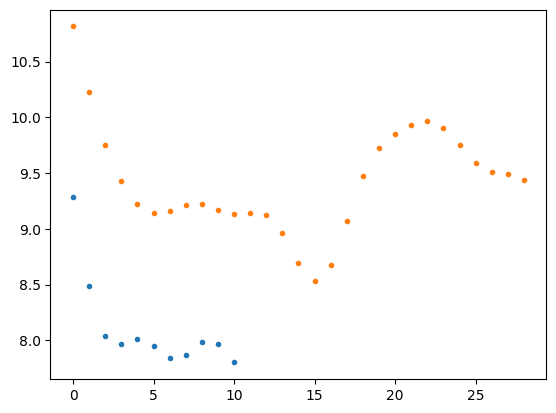

In [7]:

# Plot example track
i = 20
plt.plot(height_list[0][:,i], '.')
plt.plot(detrended_height[0][:,i], '.')
print(height_list[0][:,i].mask)

### Compute autocorrelation of data

In [8]:
h_correlation  = []
A_correlation  = []
V_correlation  = []
cd_correlation = []
md_correlation = []

i = 0
for h, A, V in zip(detrended_height, 
                   detrended_area,
                   detrended_volume):

    # Microscopes have different frame rate, hence different tmax
    config = json.load(open(f"configs/{datasets[i]}.json"))

    ### SET MICROSCOPE ###
    if config['microscope'] == "holomonitor": microscope = Holomonitor()
    elif config['microscope'] == "tomocube":  microscope = Tomocube()
    tmax = int(10 / microscope.frame_to_h)
        
    # Initialize correlation object
    autocorr_obj = Autocorrelations(path="dummy")

    # Subtract mean
    h_variation = np.ma.array(h - np.ma.mean(h, axis=0, keepdims=True), mask=False)
    A_variation = np.ma.array(A - np.ma.mean(A, axis=0, keepdims=True), mask=False)
    V_variation = np.ma.array(V - np.ma.mean(V, axis=0, keepdims=True), mask=False)

    # Compute temporal correlation
    autocorr_obj.compute_temporal(h_variation, 'hh', tmax, mean_var='cell', t_avrg=False, overwrite=True)
    autocorr_obj.compute_temporal(A_variation, 'AA', tmax, mean_var='cell', t_avrg=False, overwrite=True)
    autocorr_obj.compute_temporal(V_variation, 'VV', tmax, mean_var='cell', t_avrg=False, overwrite=True)

    # Save to list
    h_correlation.append(autocorr_obj.temporal_cell['hh'])
    A_correlation.append(autocorr_obj.temporal_cell['AA'])
    V_correlation.append(autocorr_obj.temporal_cell['VV'])

    # Add mass for tomocube
    try:
        cd = detrended_cd[i]
        md = detrended_drymass[i]

        cd_variation = np.ma.array(cd - np.ma.mean(cd, axis=0, keepdims=True), mask=False)
        md_variation = np.ma.array(md - np.ma.mean(md, axis=0, keepdims=True), mask=False)

        # compute temporal correlation with cummy variable "hh" and "VV"
        autocorr_obj.compute_temporal(cd_variation, 'hh', tmax, mean_var='cell', t_avrg=False, overwrite=True)
        autocorr_obj.compute_temporal(md_variation, 'VV', tmax, mean_var='cell', t_avrg=False, overwrite=True)

        cd_correlation.append(autocorr_obj.temporal_cell['hh'])
        md_correlation.append(autocorr_obj.temporal_cell['VV'])
        
    except:
        print("error in drymass")

    i += 1


  0%|          | 0/39 [00:00<?, ?it/s]/home/silja/Documents/MDCK-QPI/venv/lib/python3.10/site-packages/numpy/ma/core.py:5445: RuntimeWarning: Mean of empty slice.
  result = super().mean(axis=axis, dtype=dtype, **kwargs)[()]
/home/silja/Documents/MDCK-QPI/venv/lib/python3.10/site-packages/numpy/_core/_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
100%|██████████| 39/39 [00:00<00:00, 436.95it/s]


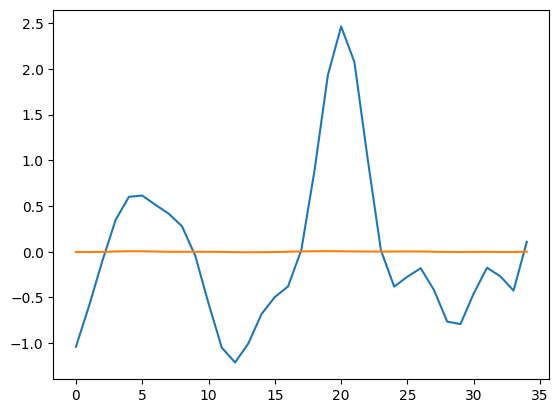

In [9]:
plt.plot(h_variation[:,1])
plt.plot(cd_variation[:,1])

### Take average of density bins

In [10]:
density_bin = 100
min_bin = np.min([min(rho[rho > 0]) for rho in density_list])
max_bin = np.max([max(rho)          for rho in density_list])

# round to nearest 100
min_bin = 100 * int(min_bin / 100)
max_bin = 100 * int(max_bin / 100) + density_bin
bins = np.arange(min_bin, max_bin + 100+1, density_bin)

# count instances in bins
density_idx = [np.digitize(rho, bins) for rho in density_list]

h_binned_correlation  = []
A_binned_correlation  = []
V_binned_correlation  = []
cd_binned_correlation = []
md_binned_correlation = []

h_binned_std = []
A_binned_std = []
V_binned_std = []
cd_binned_std = []
md_binned_std = []

for i in range(len(bins)):
    Chh_tmp = []
    CAA_tmp = []
    CVV_tmp = []
    Ccc_tmp = []
    Cmm_tmp = []

    j = 0
    for Chh, CAA, CVV, rho_idx in zip(h_correlation, 
                                      A_correlation, 
                                      V_correlation, 
                                      density_idx):
        
        # Add entires in bin to list
        mask = (rho_idx == i)
        Chh_tmp.append(Chh[mask])
        CAA_tmp.append(CAA[mask])
        CVV_tmp.append(CVV[mask])

        # Add mass if tomocube
        try:
            Ccc = cd_correlation[j]
            Cmm = md_correlation[j]

            Ccc_tmp.append(Ccc[mask])
            Cmm_tmp.append(Cmm[mask])
            dummy_counter = 0
        except:
            None

        j += 1

    Chh_tmp = np.ma.concatenate(Chh_tmp)
    CAA_tmp = np.ma.concatenate(CAA_tmp)
    CVV_tmp = np.ma.concatenate(CVV_tmp)

    h_binned_correlation.append(np.ma.mean(Chh_tmp, axis=0))
    A_binned_correlation.append(np.ma.mean(CAA_tmp, axis=0))
    V_binned_correlation.append(np.ma.mean(CVV_tmp, axis=0))

    h_binned_std.append(np.ma.std(Chh_tmp, axis=0, ddof=1) / np.sum(~Chh_tmp.mask, axis=0))
    A_binned_std.append(np.ma.std(CAA_tmp, axis=0, ddof=1) / np.sum(~CAA_tmp.mask, axis=0))
    V_binned_std.append(np.ma.std(CVV_tmp, axis=0, ddof=1) / np.sum(~CVV_tmp.mask, axis=0))

    try:
        dummy_counter += 1

        Ccc_tmp = np.ma.concatenate(Ccc_tmp)
        Cmm_tmp = np.ma.concatenate(Cmm_tmp)

        cd_binned_correlation.append(np.ma.mean(Ccc_tmp, axis=0))
        md_binned_correlation.append(np.ma.mean(Cmm_tmp, axis=0))
        
    except:
        None

/home/silja/Documents/MDCK-QPI/venv/lib/python3.10/site-packages/numpy/ma/core.py:5536: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = super().var(axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/silja/Documents/MDCK-QPI/venv/lib/python3.10/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/silja/Documents/MDCK-QPI/venv/lib/python3.10/site-packages/numpy/_core/_methods.py:212: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


In [11]:
h_no_nan = np.nan_to_num(h_binned_correlation)
md_no_nan = np.nan_to_num(md_binned_correlation)
h_binned_correlation = np.ma.array(h_binned_correlation, mask=h_no_nan==0)
A_binned_correlation = np.ma.array(A_binned_correlation, mask=h_no_nan==0)
V_binned_correlation = np.ma.array(V_binned_correlation, mask=h_no_nan==0)
md_binned_correlation = np.ma.array(md_no_nan, mask=md_no_nan==0)

In [12]:
C_hh = np.ma.concatenate([h_correlation[0],  h_correlation[1]])
C_AA = np.ma.concatenate([A_correlation[0],  A_correlation[1]])
C_VV = np.ma.concatenate([V_correlation[0],  V_correlation[1]])
C_MM = np.ma.concatenate([md_correlation[0], md_correlation[1]])

C_hh = np.ma.mean(C_hh, axis=0)
C_AA = np.ma.mean(C_AA, axis=0)
C_VV = np.ma.mean(C_VV, axis=0)
C_MM = np.ma.mean(C_MM, axis=0)

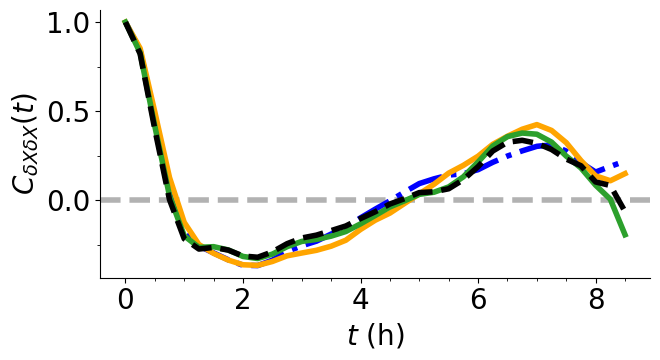

In [13]:
time = np.arange(tmax-1) / 4



font = {'family' : 'sans-serif',
        'weight' : 'normal',
        'size'   : 20}

mpl.rc('font', **font)

# Plot correlation
fig, ax = plt.subplots(1,1, figsize=(7,4))


ax.axhline(0, c="gray", ls="dashed", lw=4, alpha=0.6)

i, f = 12, -2
ax.plot(time, C_hh,  '-.',  c=h_color,  lw=4, label=r"$X=\delta h$")
ax.plot(time, C_AA,  '-',   c=A_color,  lw=4, label=r"$X=\delta A$")
ax.plot(time, C_VV,  '-',   c=V_color,  lw=4, label=r"$X=\delta V$")
ax.plot(time, C_MM,  '--',  c=M_color,  lw=4, label=r"$X=\delta M$")
# ax.plot(time, np.ma.mean(A_binned_correlation[i:f], axis=0),  '--', c=A_color,  lw=4)
# ax.plot(time, np.ma.mean(V_binned_correlation[i:f], axis=0),  '-',  c=V_color,  lw=4)
# try:
#        ax.plot(time, np.ma.mean(Vd_binned_correlation[i:f], axis=0), ':', c=Vd_color, lw=4)
# except:
#        None
ax.yaxis.set_minor_locator(MultipleLocator(0.25))
ax.xaxis.set_minor_locator(MultipleLocator(0.5))


ax.set(xlabel=r"$t$ (h)", 
       ylabel=r"$C_{\delta X \delta X}(t)$",)
       #xlim=(-0.1, 10))

ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)
# ax.legend(prop={'size':14}, handleheight=1)

#fig.legend()
fig.tight_layout()
fig.savefig("figs/Elife/subfigures/hAVM_autocorrelation.svg")

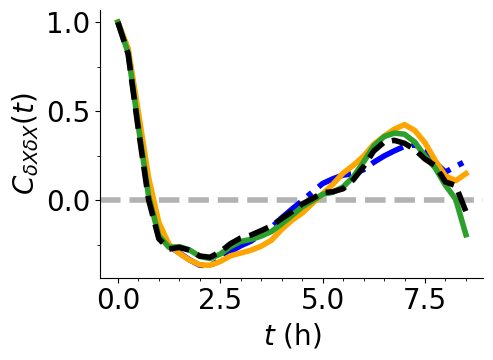

In [15]:
time = np.arange(tmax-1) / 4



font = {'family' : 'sans-serif',
        'weight' : 'normal',
        'size'   : 20}

mpl.rc('font', **font)

# Plot correlation
fig, ax = plt.subplots(1,1, figsize=(4*1/0.75,4))

# (4,3)
ax.axhline(0, c="gray", ls="dashed", lw=4, alpha=0.6)

i, f = 12, -2
ax.plot(time, C_hh,  '-.',  c=h_color,  lw=4, label=r"$X=\delta h$")
ax.plot(time, C_AA,  '-',   c=A_color,  lw=4, label=r"$X=\delta A$")
ax.plot(time, C_VV,  '-',   c=V_color,  lw=4, label=r"$X=\delta V$")
ax.plot(time, C_MM,  '--',  c=M_color,  lw=4, label=r"$X=\delta M$")
# ax.plot(time, np.ma.mean(A_binned_correlation[i:f], axis=0),  '--', c=A_color,  lw=4)
# ax.plot(time, np.ma.mean(V_binned_correlation[i:f], axis=0),  '-',  c=V_color,  lw=4)
# try:
#        ax.plot(time, np.ma.mean(Vd_binned_correlation[i:f], axis=0), ':', c=Vd_color, lw=4)
# except:
#        None
ax.yaxis.set_minor_locator(MultipleLocator(0.25))
ax.xaxis.set_minor_locator(MultipleLocator(0.5))


ax.set(xlabel=r"$t$ (h)", 
       ylabel=r"$C_{\delta X \delta X}(t)$",)
       #xlim=(-0.1, 10))

ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)
# ax.legend(prop={'size':14}, handleheight=1)

#fig.legend()
fig.tight_layout()
fig.savefig("figs/Elife/subfigures/hAVM_autocorrelation_small.svg")